# Conditions for inference on slope

[Conditions for inference on slope | More on regression | AP Statistics | Khan Academy | YouTube](https://www.youtube.com/watch?v=kOQx3LtWHEQ&t=5s)

**Bullet summary**

- Inference for regression requires a set of assumptions summarized by
  **LINER**: **Linear**, **Independent**, **Normal**, **Equal
  variance**, **Random**.

- **Linear** means the true relationship between $x$and $y$in the
  population is actually linear.

- **Independent** means observations are independent, either through
  sampling with replacement or the 10% condition.

- **Normal** means for any fixed $x$, the distribution of $y$values
  around the regression line is normal.

- **Equal variance** means the spread of $y$around the regression line
  is the same for all $x$values (no funnel shape).

- **Random** means the data come from a well‑designed random sample or
  randomized experiment.

- These conditions justify using **t‑based inference** for the slope of
  the regression line, including confidence intervals and hypothesis
  tests.

- When conditions hold, the sampling distribution of the slope $b$is
  approximately normal with standard error $SE_{b}$, allowing
  inference about the population slope $\beta$.

**Explanation**

Inference for regression focuses on estimating or testing the
**population slope** $\beta$, which describes the true linear
relationship between two quantitative variables. Because we only observe
a sample, the slope $b$from the sample regression line varies from
sample to sample. To make valid inferences—such as constructing a
confidence interval or testing whether $\beta = 0$—we need certain
conditions to hold.

The **LINER** conditions provide a framework:

- **Linear**: The underlying relationship between $x$and $y$is
  linear. If the true relationship curves or bends, a straight‑line
  model may misrepresent the pattern, and inference becomes unreliable.

- **Independent**: Observations must be independent. This is satisfied
  by random sampling or by ensuring the sample is less than 10% of the
  population when sampling without replacement.

- **Normal**: For each fixed $x$, the distribution of the residuals
  (or $y$values around the regression line) should be normal. This
  ensures the sampling distribution of the slope is well‑behaved.

- **Equal variance**: The spread of residuals should be roughly constant
  across all $x$values. If the spread increases or decreases (a funnel
  shape), the standard error of the slope becomes inaccurate.

- **Random**: The data must come from a random sample or randomized
  experiment to generalize results to the population.

When these conditions are met, the slope $b$has a sampling
distribution that is approximately normal with standard error
$SE_{b}$. This allows us to compute:

- **Confidence intervals**:

$$
b \pm t^* \cdot SE_{b}
$$

- **Hypothesis tests** for

$$
H_{0}:\beta = 0\text{vs.}H_{a}:\beta \neq 0\text{ or }\beta > 0.
$$

The test statistic is

$$
t = \frac{b - 0}{SE_{b}},
$$

with $n - 2$degrees of freedom.

**Code example (Python)**

The following example fits a regression line, checks residual patterns,
and performs inference on the slope:

Slope estimate: 2.461
Standard error: 0.037
95% CI for slope: (np.float64(2.3755946936464656), np.float64(2.54561742756565))
t-statistic: 66.746
P-value: 0.0000


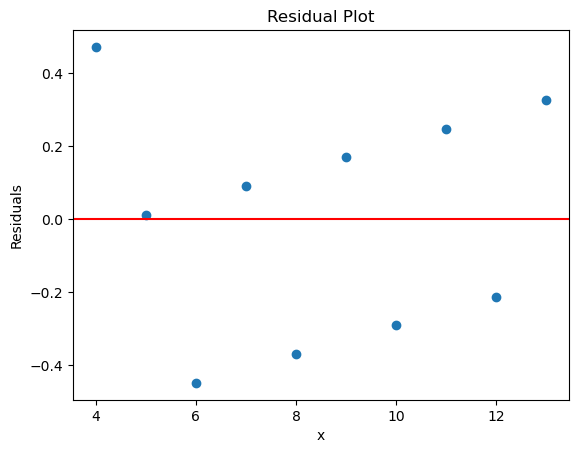

In [1]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# Example data
x = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 13])
y = np.array([48, 50, 52, 55, 57, 60, 62, 65, 67, 70])

# Add intercept
X = sm.add_constant(x)

# Fit regression model
model = sm.OLS(y, X).fit()

# Extract slope and standard error
b = model.params[1]
SE_b = model.bse[1]
df = len(x) - 2

# 95% confidence interval
t_crit = stats.t.ppf(0.975, df)
CI = (b - t_crit * SE_b, b + t_crit * SE_b)

# Hypothesis test for beta = 0
t_stat = b / SE_b
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print(f"Slope estimate: {b:.3f}")
print(f"Standard error: {SE_b:.3f}")
print(f"95% CI for slope: {CI}")
print(f"t-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Residual plot to check linearity and equal variance
residuals = model.resid
plt.scatter(x, residuals)
plt.axhline(0, color='red')
plt.xlabel("x")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Is there a particular regression scenario you want to analyze next—like
building a confidence interval for a real dataset or running a
hypothesis test for a slope?

# [Context](https://github.com/progressivepull/Statistics-Deep-Dives/blob/main/khan_academy/Content.md)